# Centralidades de Katz y Pagerank

La siguiente es una red de colaboración en la cual los nodos representan investigadores y están unidos mediante una arista si son coautores en un mismo trabajo.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

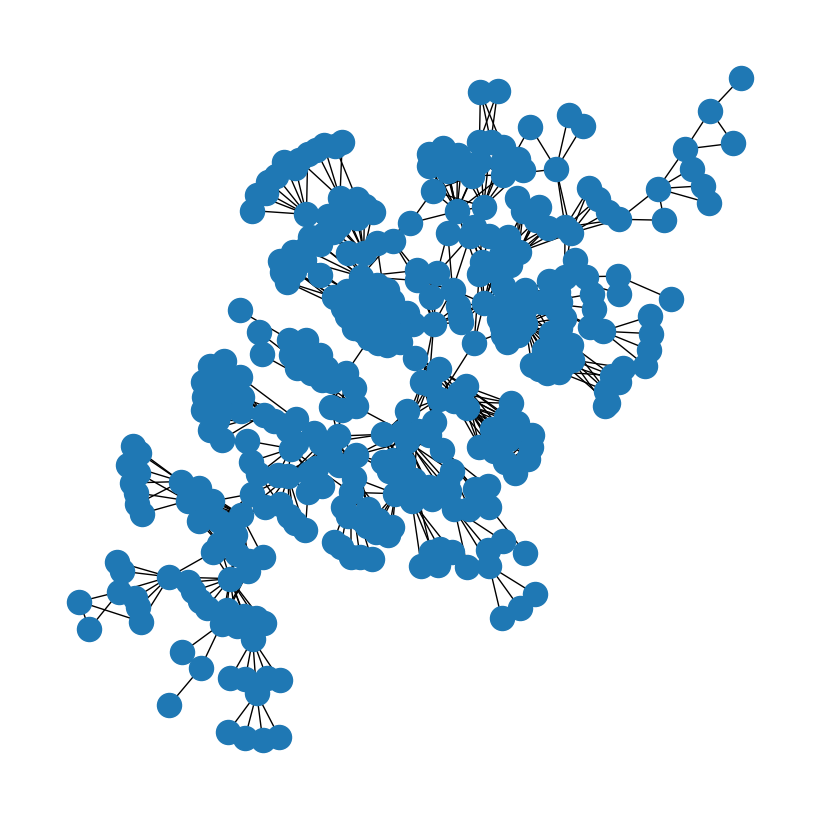

In [2]:
datos = pd.read_csv('data/ca-netscience.mtx', skiprows=2, header=None, sep=' ')
aristas = datos[[0, 1]].values

G1 = nx.Graph()
G1.add_edges_from(aristas)

plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout)

# Actividad

 ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado y de eigenvector? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos?




In [4]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=0.1)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)


def sum1_dict(d):
    s = sum(d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)


eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])


Convergio con un alpha=0.0900


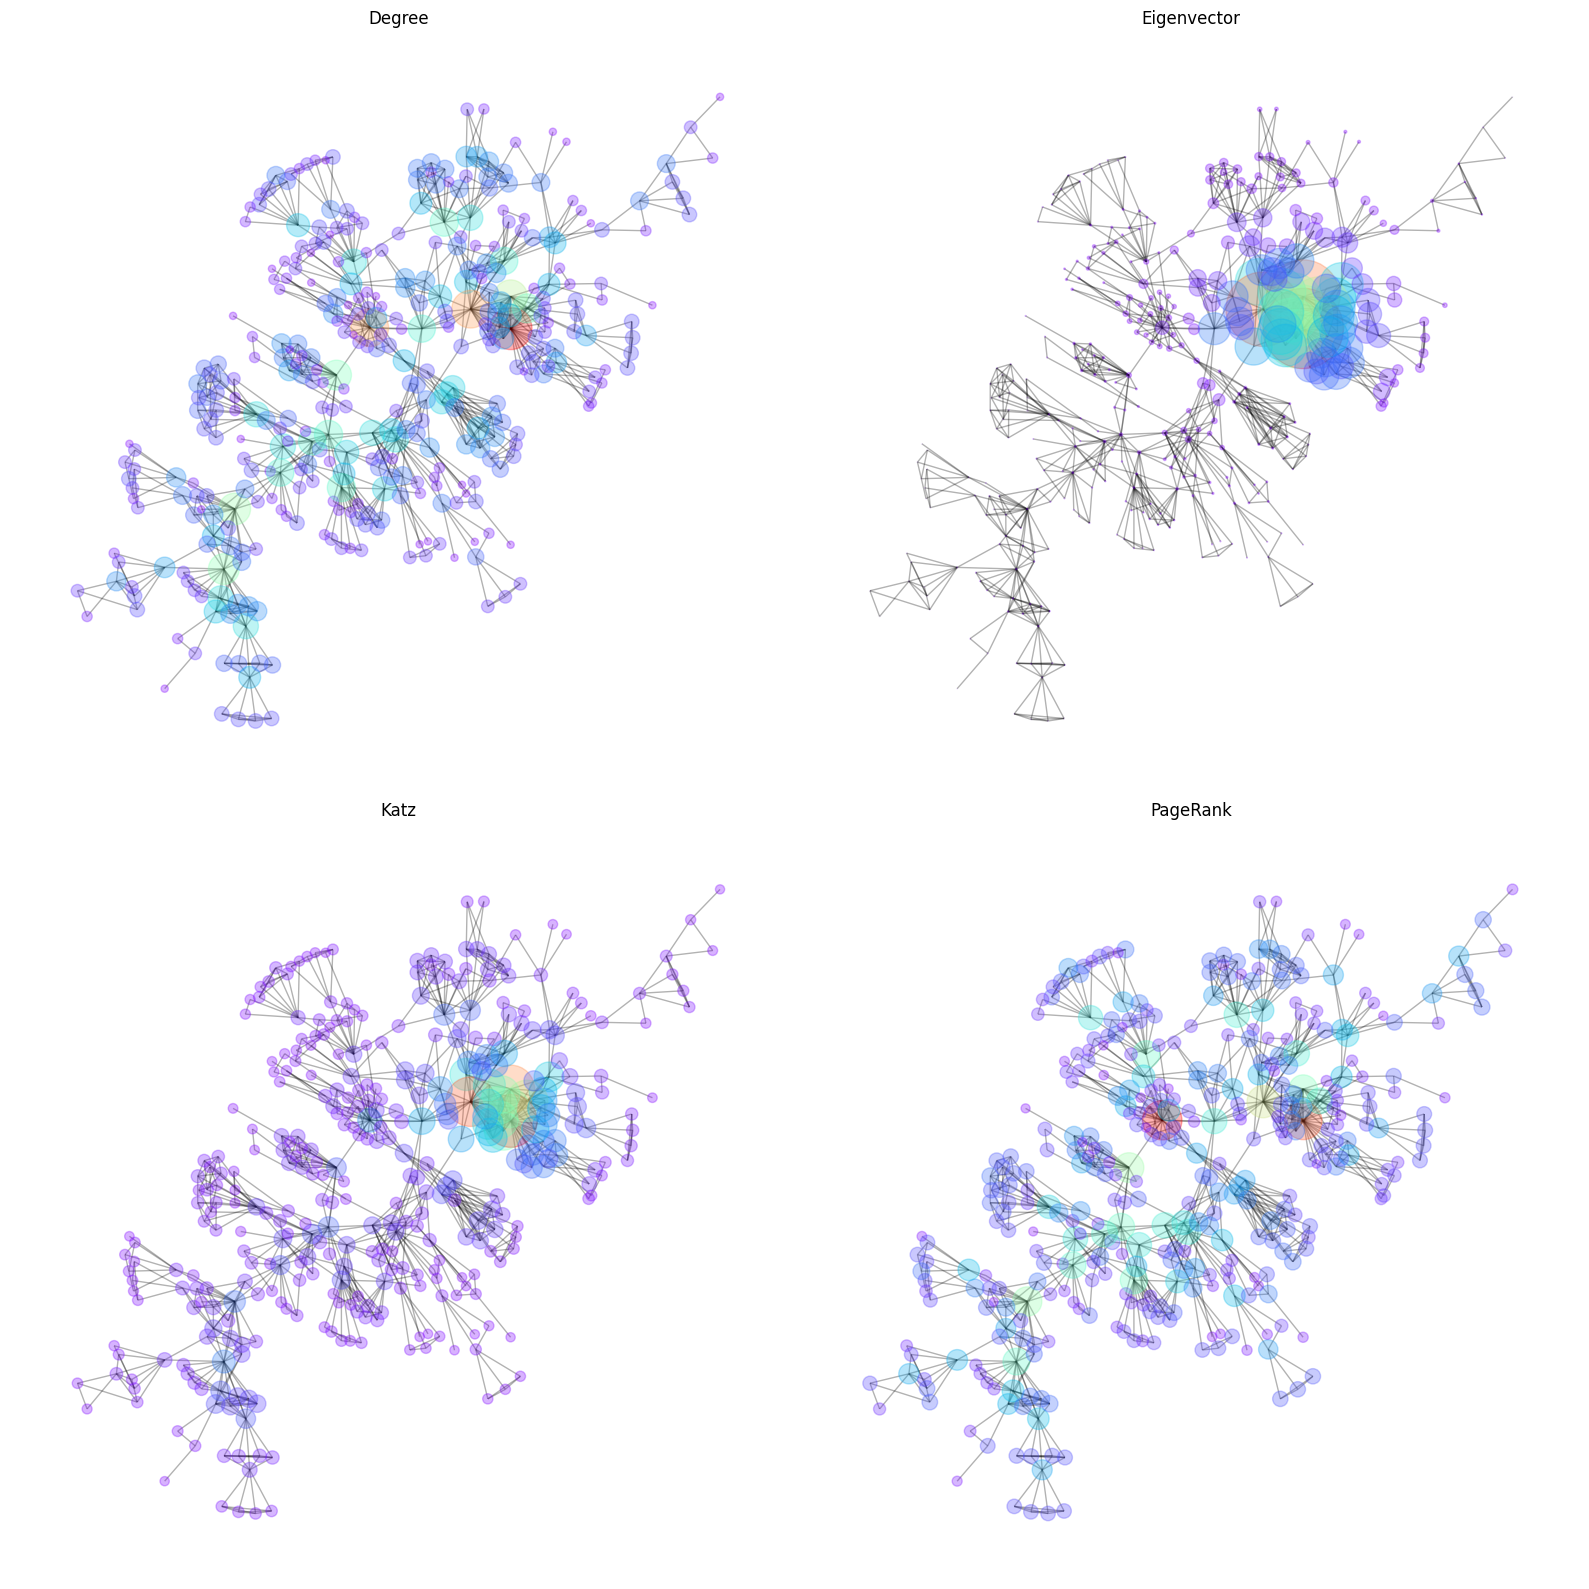

In [5]:
plt.figure(figsize=(16, 16))

nsize = 50000

plt.subplot(2, 2, 1)
nx.draw_kamada_kawai(G1, node_size=nsize*deg_colors,
                     node_color=deg_colors, with_labels=False, alpha=0.3)
plt.title("Degree")

plt.subplot(2, 2, 2)
nx.draw_kamada_kawai(G1, node_size=nsize*eig_sizes,
                     node_color=eig_sizes, with_labels=False, alpha=0.3)
plt.title("Eigenvector")

plt.subplot(2, 2, 3)
nx.draw_kamada_kawai(G1, node_size=nsize*katz_colors,
                     node_color=katz_colors, with_labels=False, alpha=0.3)
plt.title("Katz")

plt.subplot(2, 2, 4)
nx.draw_kamada_kawai(G1, node_size=nsize*pg_sizes,
                     node_color=pg_sizes, with_labels=False, alpha=0.3)
plt.title("PageRank")

plt.tight_layout()
plt.show()

## Funciones

In [6]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [7]:
# plot centralidades

def plot_centralidades(top_pos, title: str = '', nodesize=10000):
    top_pos_eig = np.array([eig_centralidades[n] for n in top_pos])
    top_pos_deg = np.array([deg_centralidades[n] for n in top_pos])
    top_pos_katz = np.array([katz_centralidades[n] for n in top_pos])
    top_pos_pg = np.array([pg_centralidades[n] for n in top_pos])

    plt.figure(figsize=(16, 16))
    pos = nx.kamada_kawai_layout(G1)

    plt.subplot(2, 2, 2)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_eig,
                           node_color=top_pos_eig, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Eigenvector")
    plt.axis("off")

    plt.subplot(2, 2, 1)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_deg,
                           node_color=top_pos_deg, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Degree")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_katz,
                           node_color=top_pos_katz, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Katz")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_pg,
                           node_color=top_pos_pg, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("PageRank")
    plt.axis("off")

    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

In [8]:
# tabla

def tabla(top_pos, digits):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
        })
        .reset_index(drop=True)
    )


    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
            }
        )
    )
    return df

In [9]:
# vecinos

import matplotlib


def ego_layers(G, center, max_radius):
    layers = []
    prev = set()
    for r in range(0, max_radius + 1):
        nodes_r = set(nx.ego_graph(G, center, radius=r).nodes())
        layers.append(nodes_r - prev)  # exactly distance r
        prev = nodes_r
    return layers  # [L0, L1, ..., Lmax]


def layer_color_map(layers, cmap_name="Reds", stops=None, default="lightgray"):
    # stops: list of floats in [0,1] for each layer (0..R). Higher => darker in Reds.
    if stops is None:
        # for radius 3: [dark, ..., light]
        stops = np.linspace(0.95, 0.35, num=len(layers))

    cmap = matplotlib.colormaps[cmap_name]
    layer_to_color = {i: cmap(stops[i]) for i in range(len(layers))}

    node_to_layer = {}
    for i, L in enumerate(layers):
        for n in L:
            node_to_layer[n] = i

    def colors_for(subG):
        cols = []
        for n in subG.nodes():
            i = node_to_layer.get(n, None)
            cols.append(
                layer_to_color[i] if i is not None else mcolors.to_rgba(default))
        return cols

    return colors_for


def plot_ego_radii_3panel(G, center, radii=(1, 2, 3), layout="kamada_kawai", figsize=(18, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)          # L0..Lmax (exact distance)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        # how many nodes at each exact distance from center (up to r)
        layer_counts = [len(layers[d]) for d in range(r + 1)]
        # neighbors in each step (excluding the center at distance 0)
        neighbor_counts = layer_counts[1:]  # distances 1..r

        plt.subplot(1, 3, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_ego_radii_4panel(G, center, radii=(1, 2, 3, 4), layout="kamada_kawai", figsize=(24, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        layer_counts = [len(layers[d]) for d in range(r + 1)]
        neighbor_counts = layer_counts[1:]

        plt.subplot(1, 4, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Top Grado

In [10]:
df_top_deg = tabla(top_deg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,4,0.0186,0.0668,0.0289,0.0145
1,5,0.0148,0.0575,0.0254,0.0108
2,26,0.0148,0.0019,0.0059,0.0162
3,16,0.0115,0.0559,0.0237,0.0083
4,67,0.0104,0.0000,0.0048,0.0089
5,70,0.0098,0.0000,0.0054,0.0074
6,95,0.0093,0.0002,0.0040,0.0092
7,15,0.0088,0.0413,0.0179,0.0068
8,113,0.0082,0.0036,0.0046,0.0067
9,51,0.0082,0.0001,0.0043,0.0076


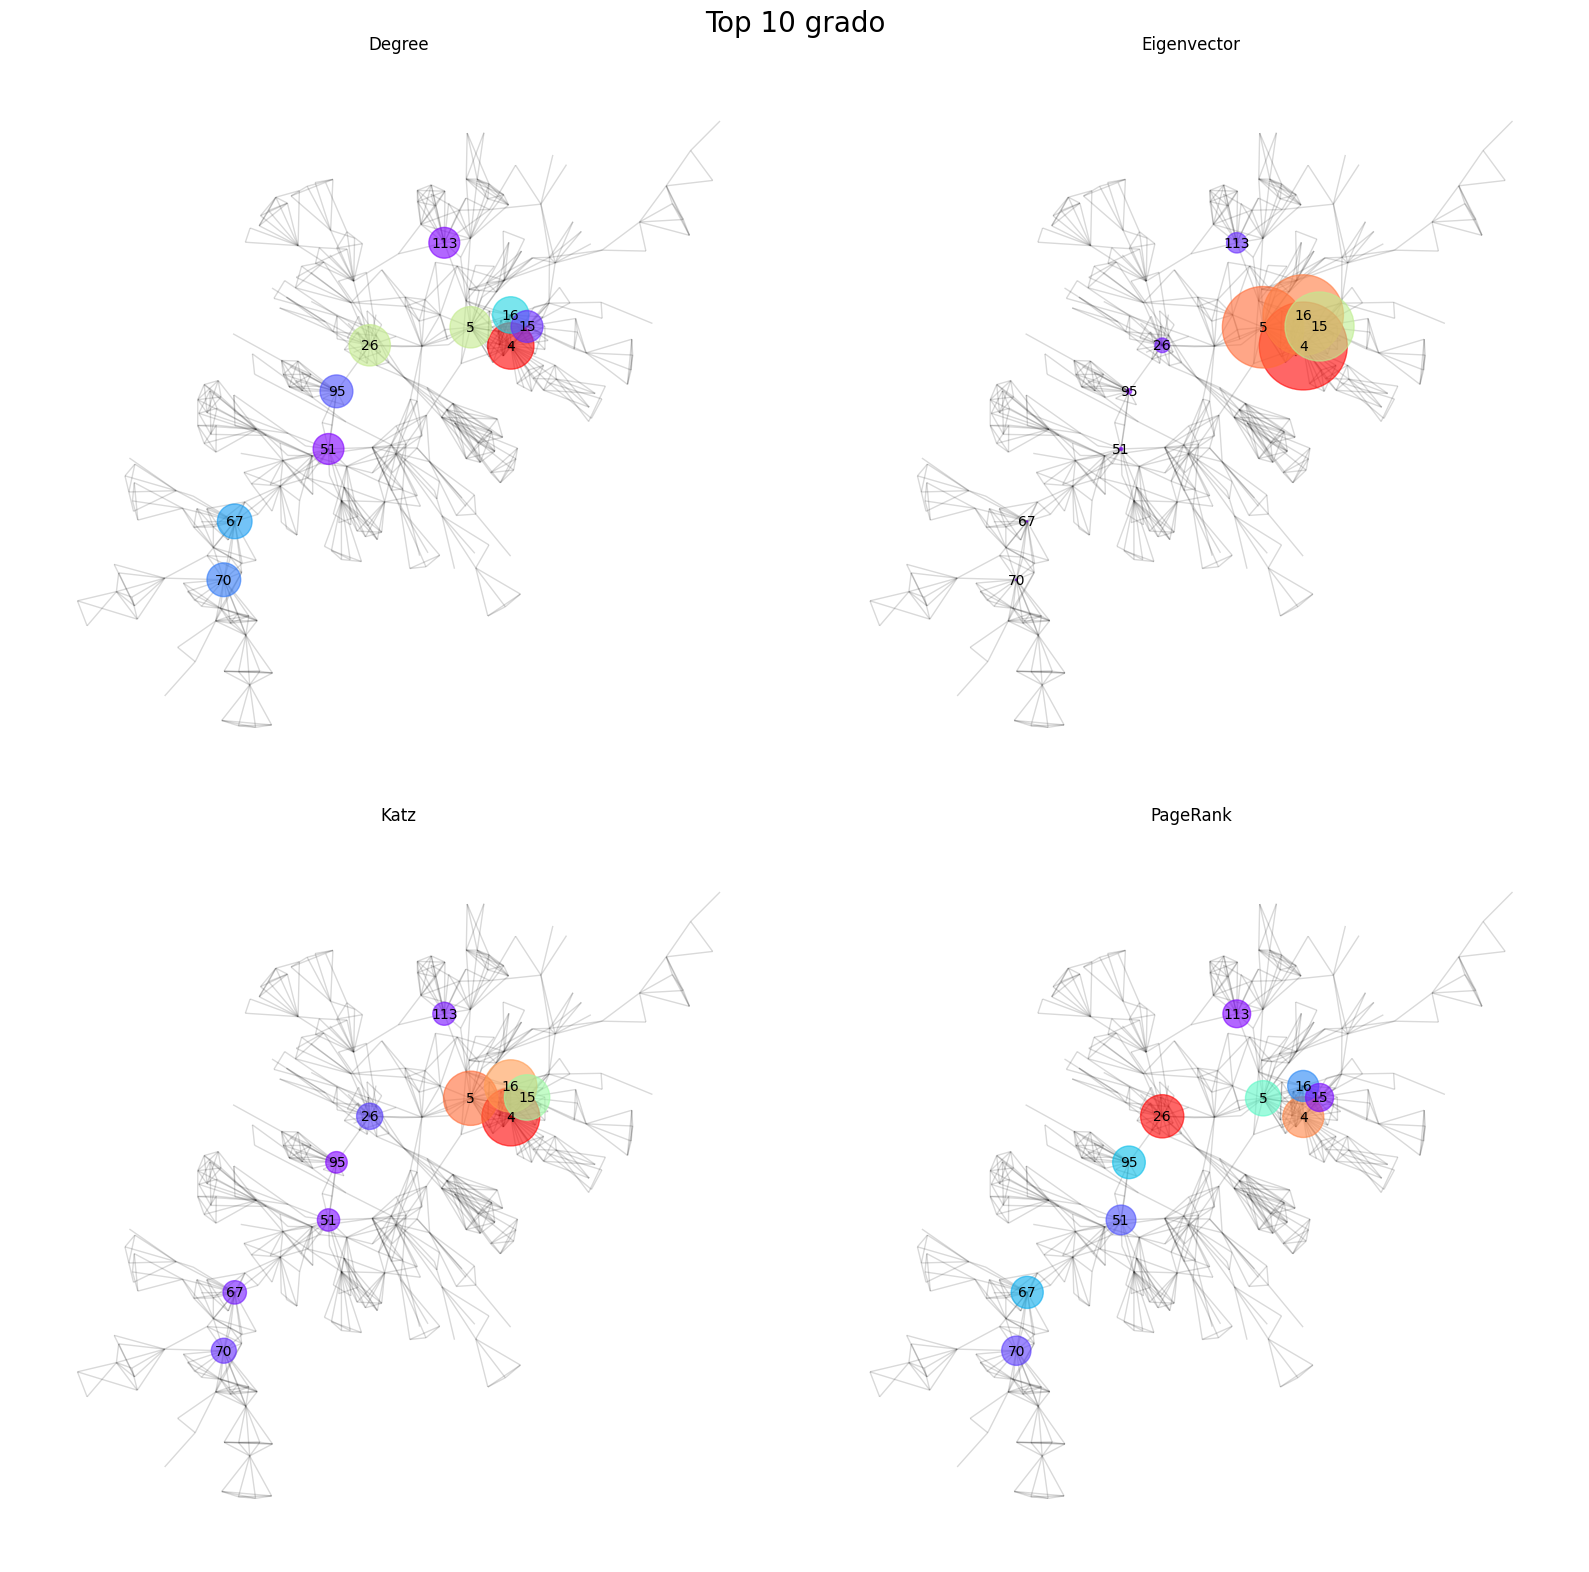

In [11]:
plot_centralidades(
    top_pos=top_deg, title='Top 10 grado', nodesize=60000)

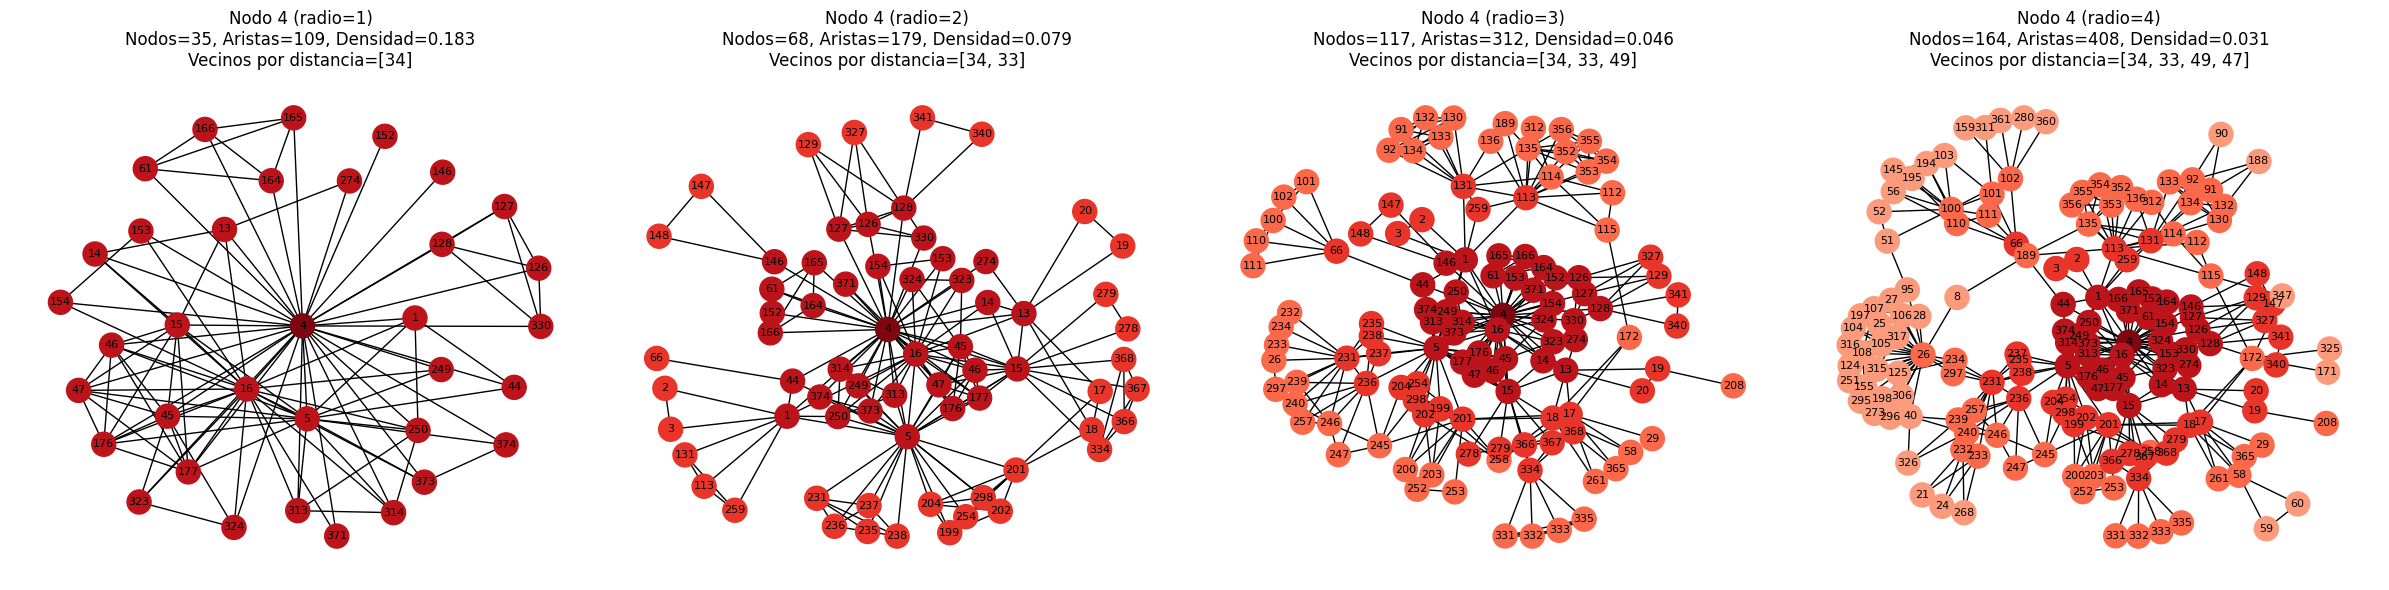

In [12]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top Eigenvector

In [13]:
df_top_eig = tabla(top_eig, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,4,0.0186,0.0668,0.0289,0.0145
1,5,0.0148,0.0575,0.0254,0.0108
2,16,0.0115,0.0559,0.0237,0.0083
3,15,0.0088,0.0413,0.0179,0.0068
4,45,0.0055,0.0382,0.0161,0.0039
5,46,0.0044,0.0352,0.0149,0.0031
6,47,0.0044,0.0352,0.0149,0.0031
7,176,0.0044,0.0352,0.0149,0.0031
8,177,0.0044,0.0352,0.0149,0.0031
9,250,0.0033,0.0237,0.0105,0.0026


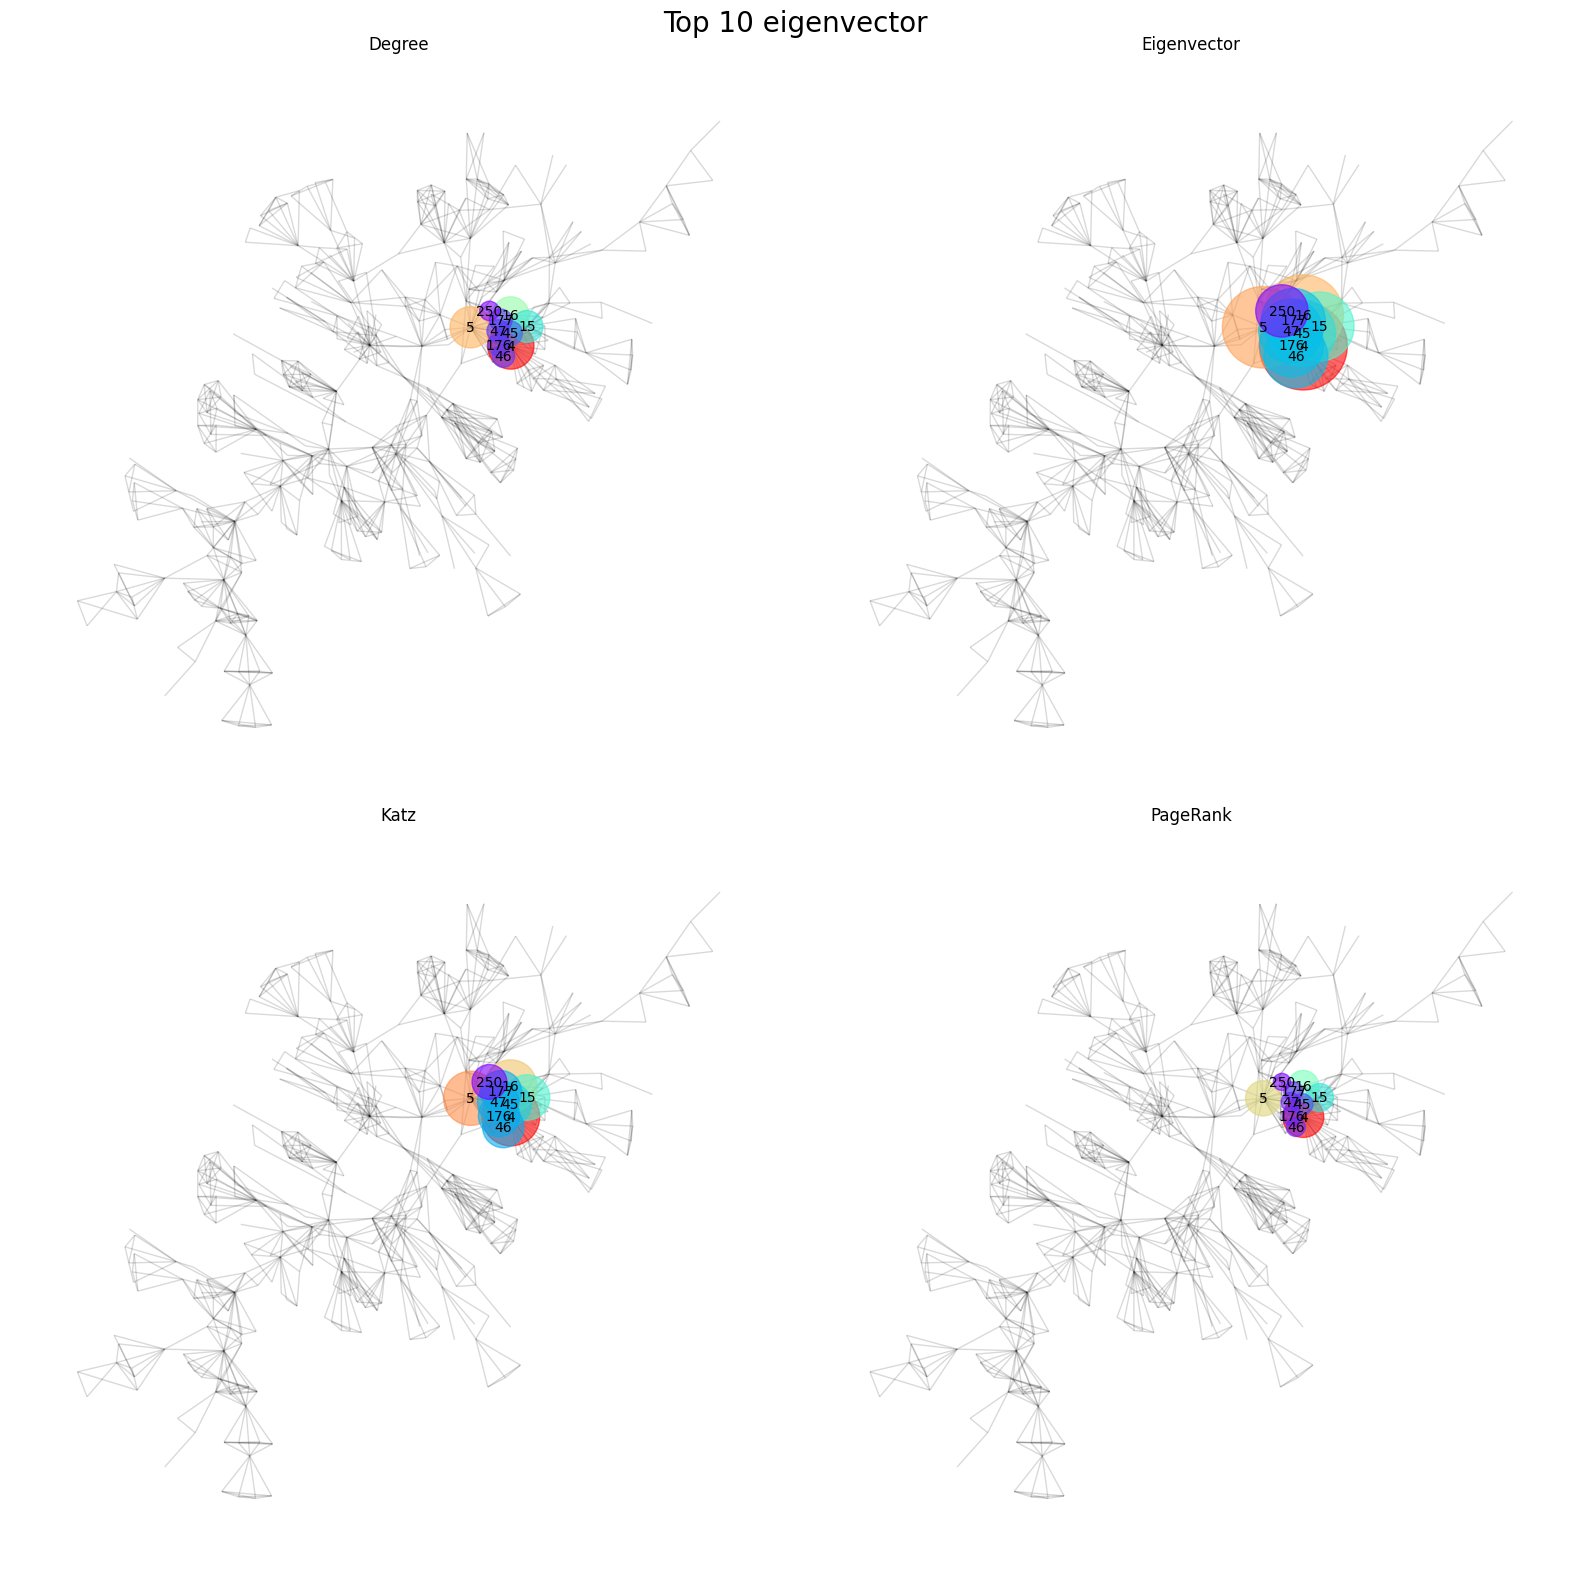

In [14]:
plot_centralidades(
    top_pos=top_eig, title='Top 10 eigenvector', nodesize=60000)

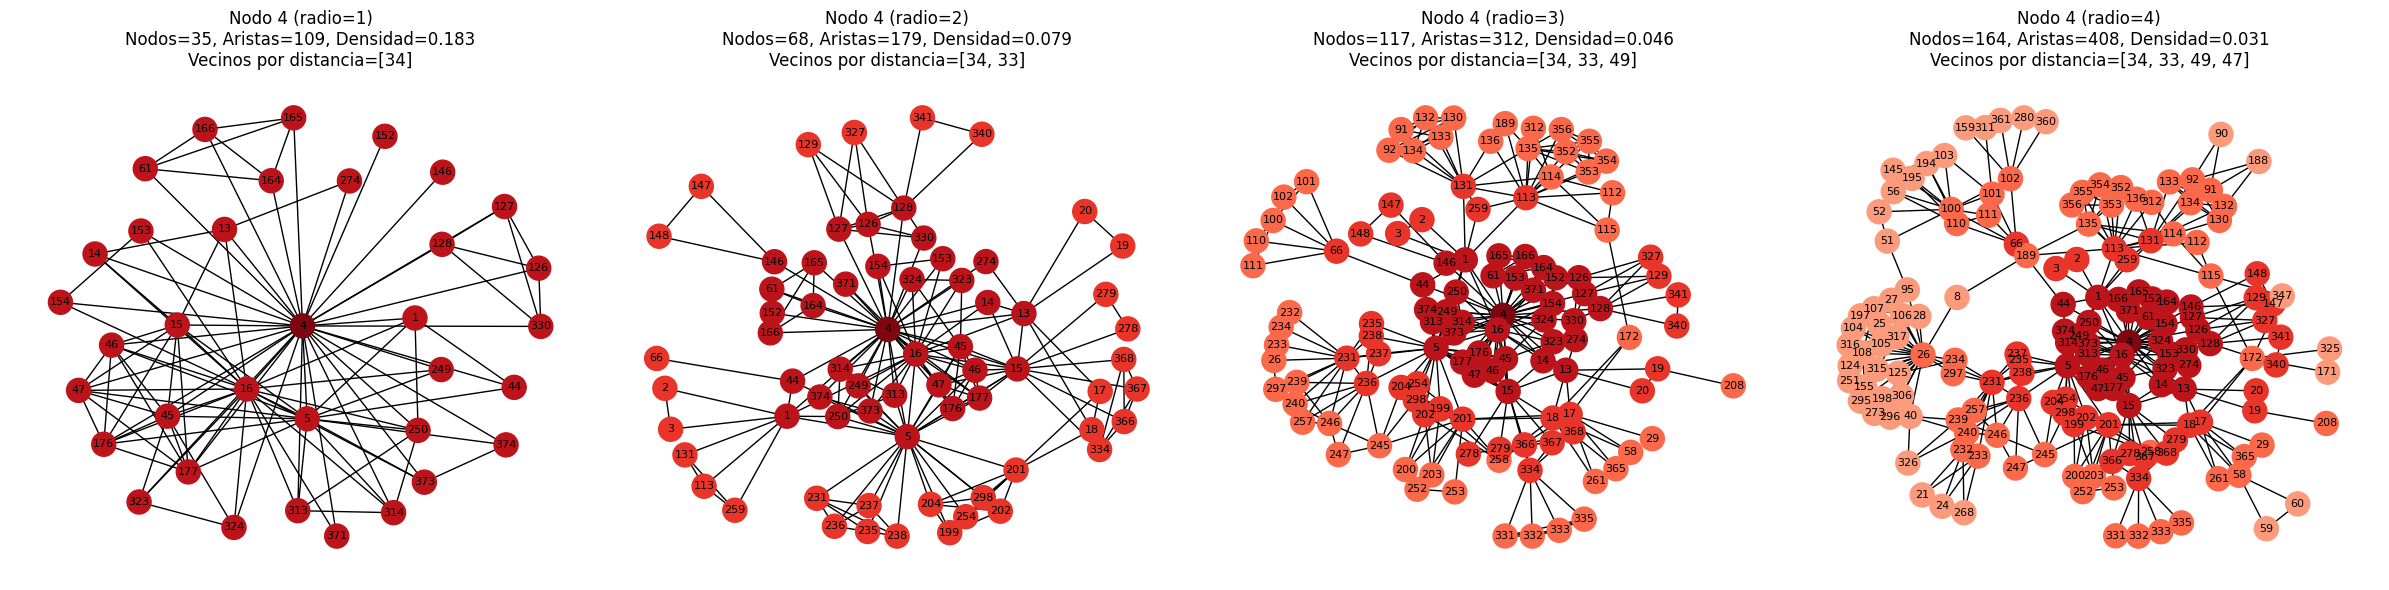

In [15]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top Katz

In [16]:
df_top_katz = tabla(top_katz, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,4,0.0186,0.0668,0.0289,0.0145
1,5,0.0148,0.0575,0.0254,0.0108
2,16,0.0115,0.0559,0.0237,0.0083
3,15,0.0088,0.0413,0.0179,0.0068
4,45,0.0055,0.0382,0.0161,0.0039
5,46,0.0044,0.0352,0.0149,0.0031
6,47,0.0044,0.0352,0.0149,0.0031
7,176,0.0044,0.0352,0.0149,0.0031
8,177,0.0044,0.0352,0.0149,0.0031
9,1,0.0055,0.0224,0.0107,0.0045


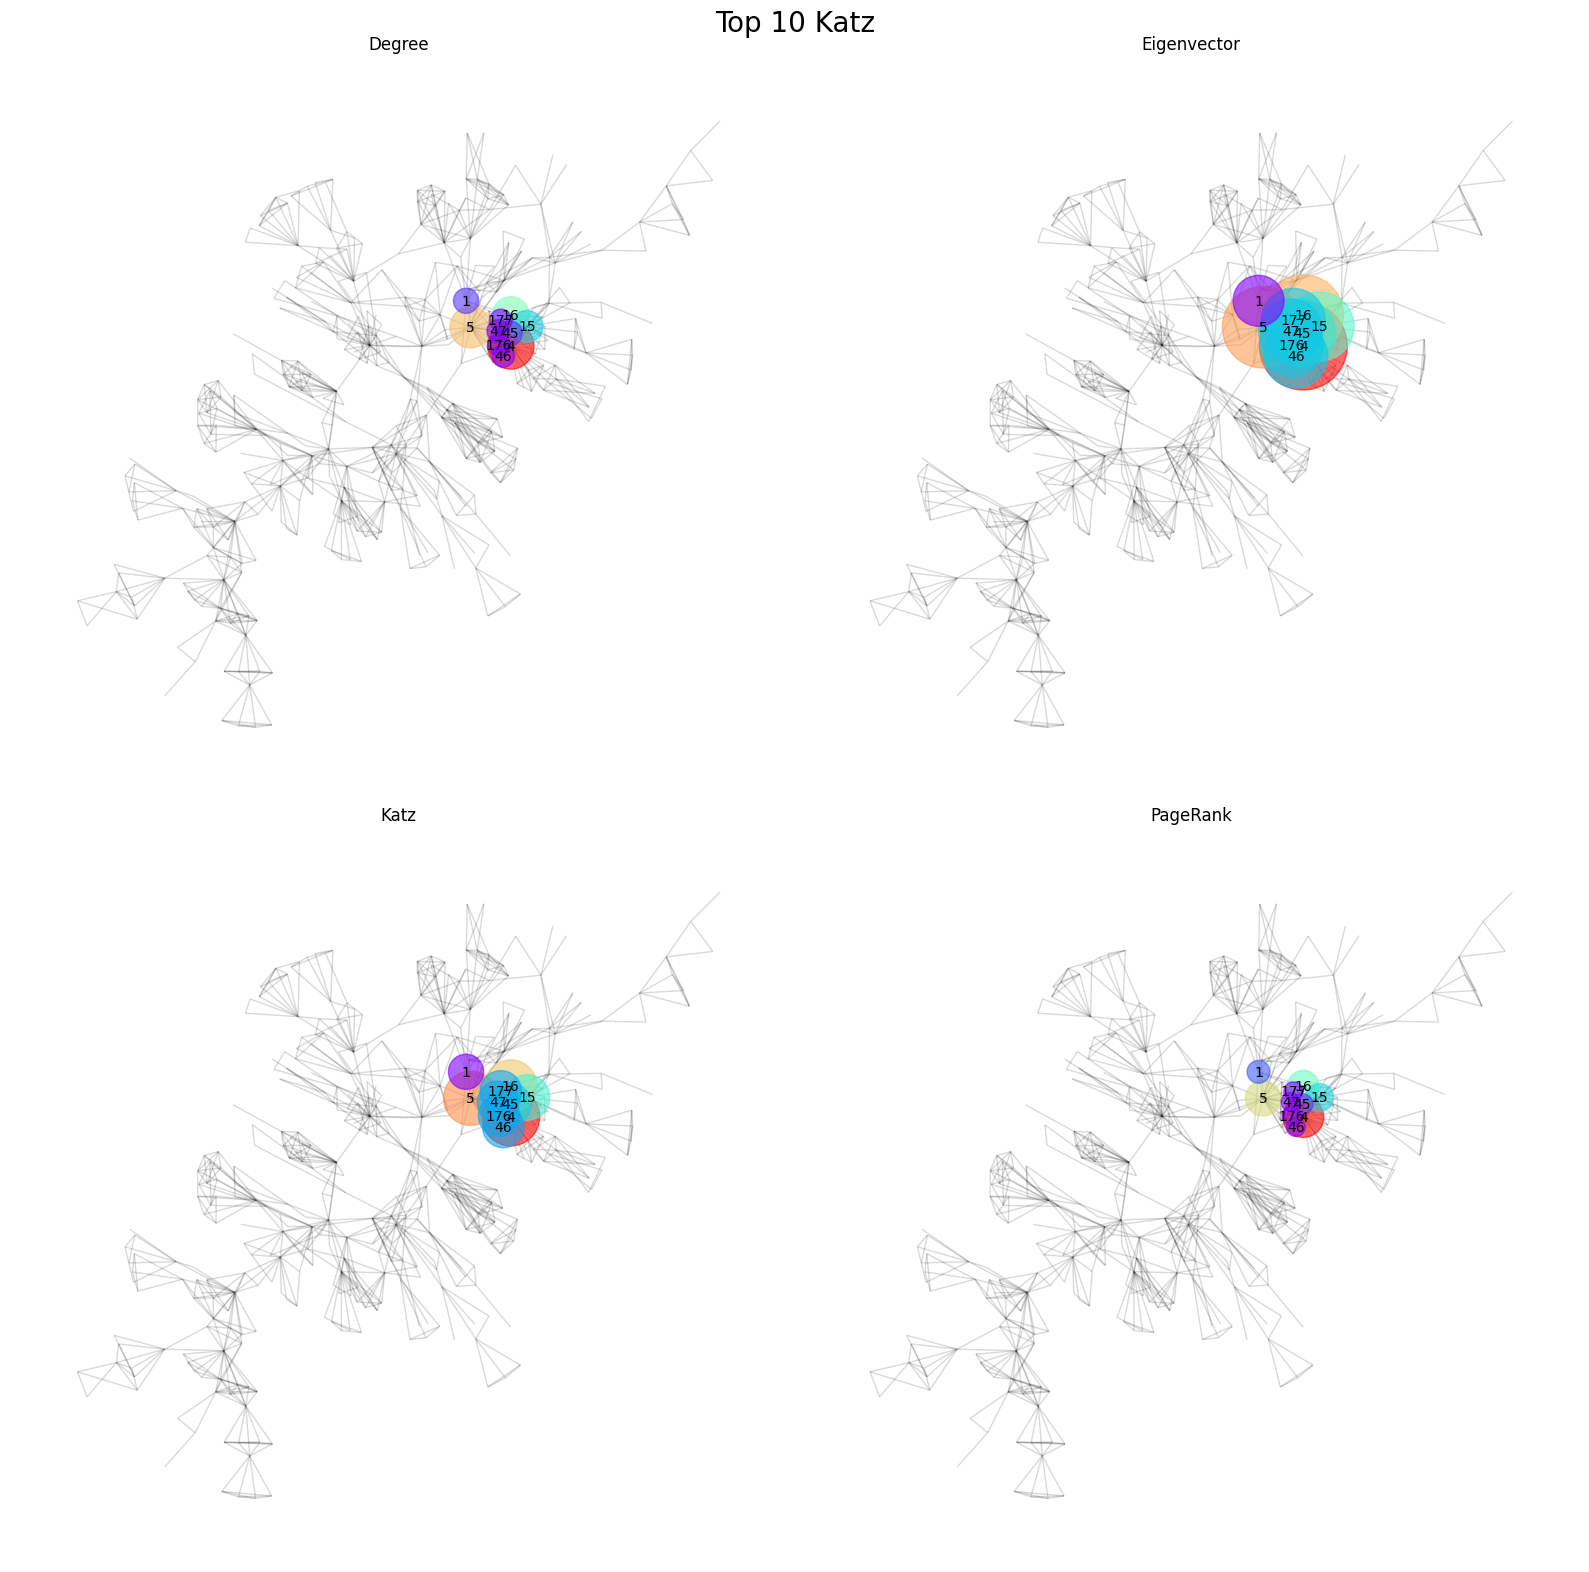

In [17]:
plot_centralidades(
    top_pos=top_katz, title='Top 10 Katz', nodesize=60000)

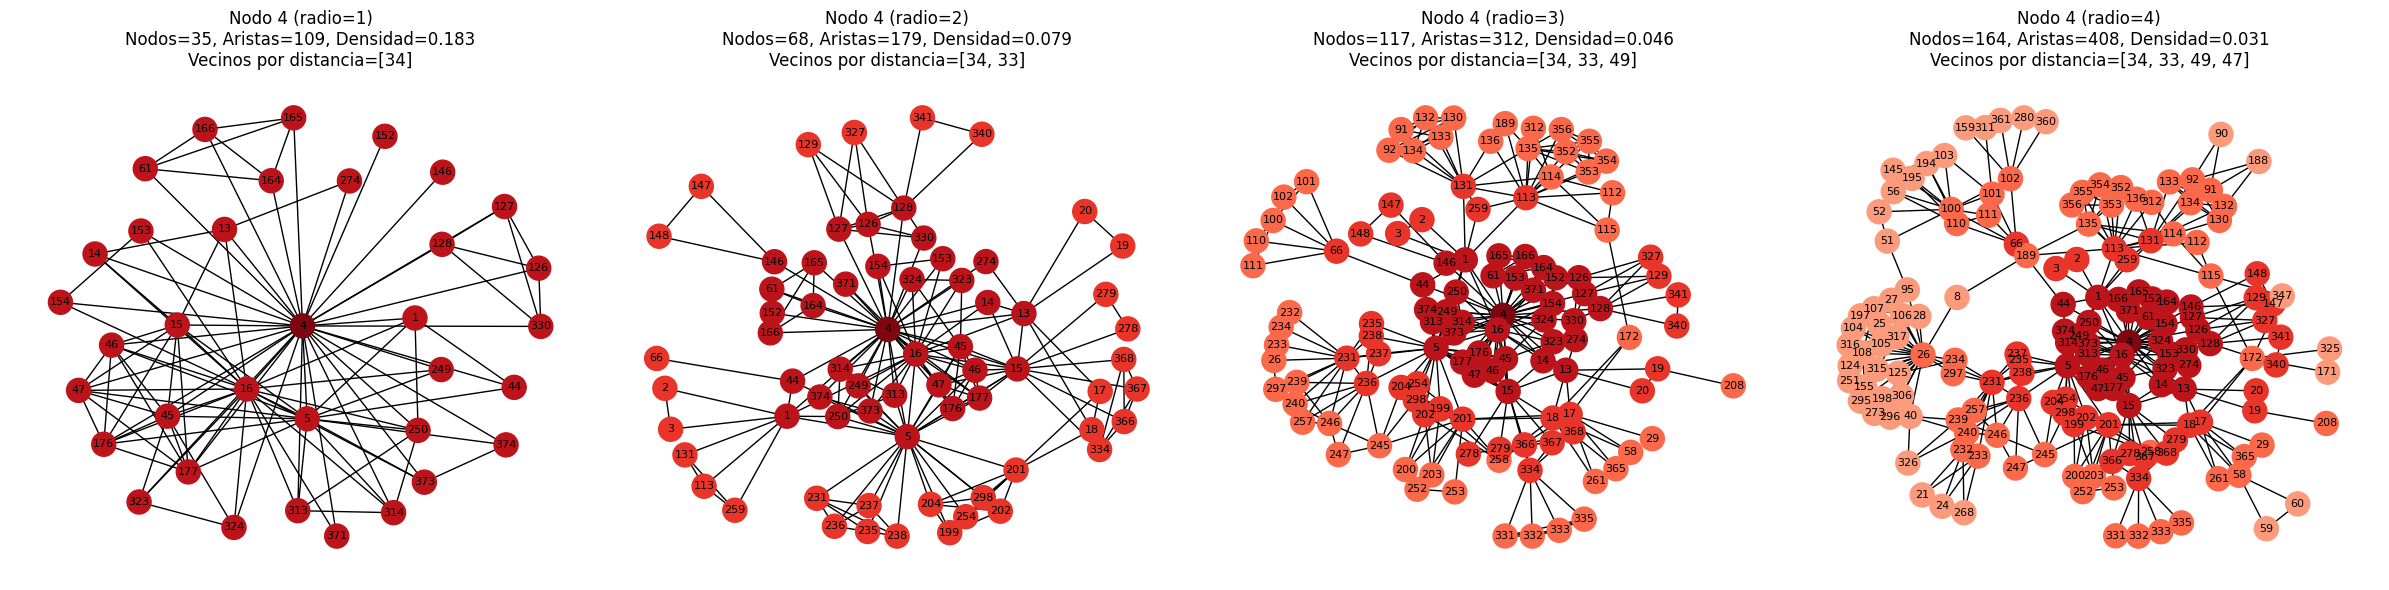

In [18]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top PageRank

In [19]:
df_top_pg = tabla(top_pg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,26,0.0148,0.0019,0.0059,0.0162
1,4,0.0186,0.0668,0.0289,0.0145
2,5,0.0148,0.0575,0.0254,0.0108
3,95,0.0093,0.0002,0.0040,0.0092
4,67,0.0104,0.0000,0.0048,0.0089
5,16,0.0115,0.0559,0.0237,0.0083
6,32,0.0082,0.0000,0.0034,0.0077
7,51,0.0082,0.0001,0.0043,0.0076
8,8,0.0066,0.0003,0.0027,0.0076
9,70,0.0098,0.0000,0.0054,0.0074


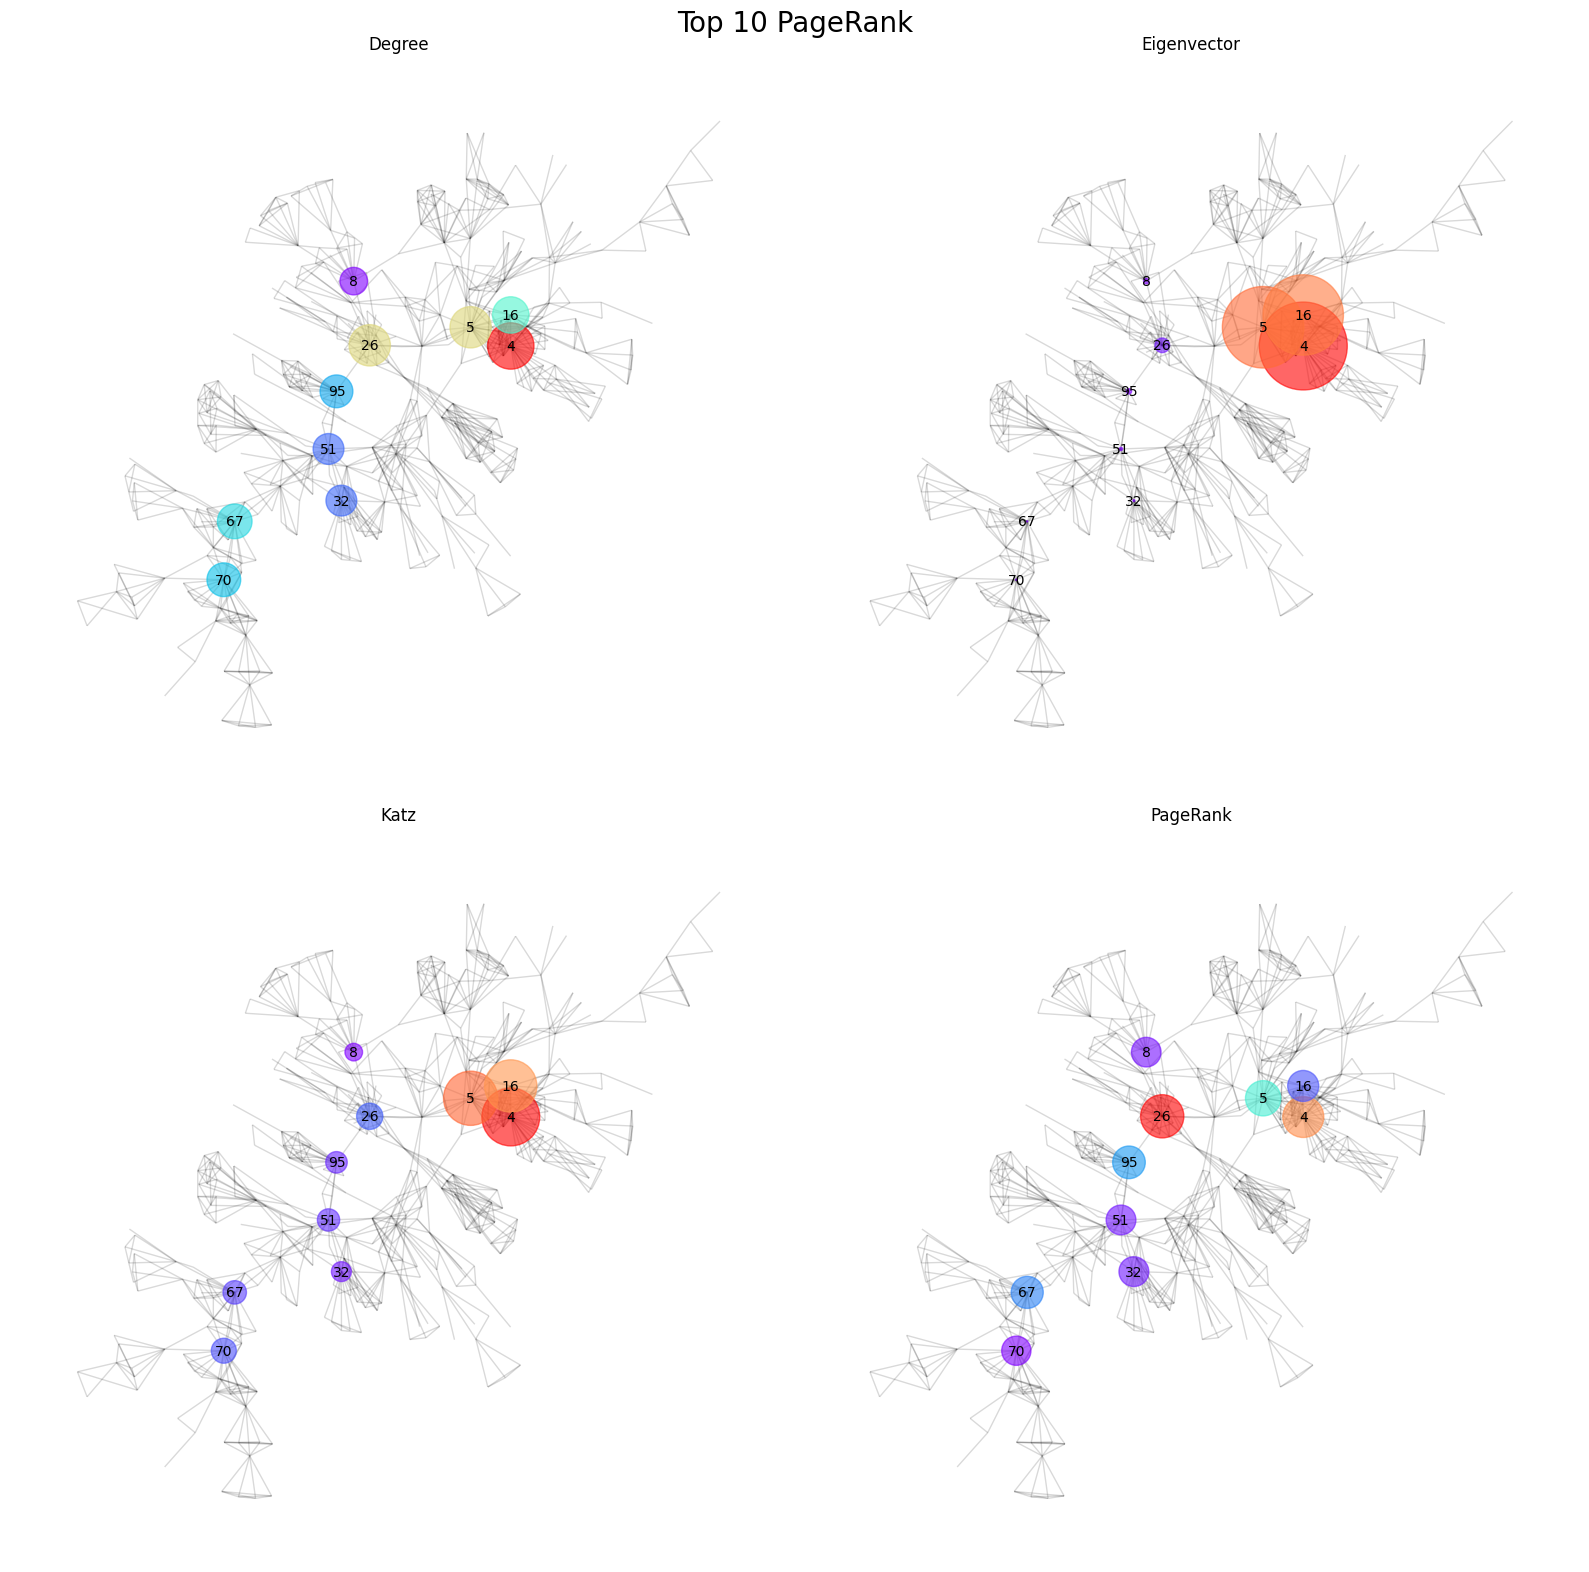

In [20]:
plot_centralidades(
    top_pos=top_pg, title='Top 10 PageRank', nodesize=60000)

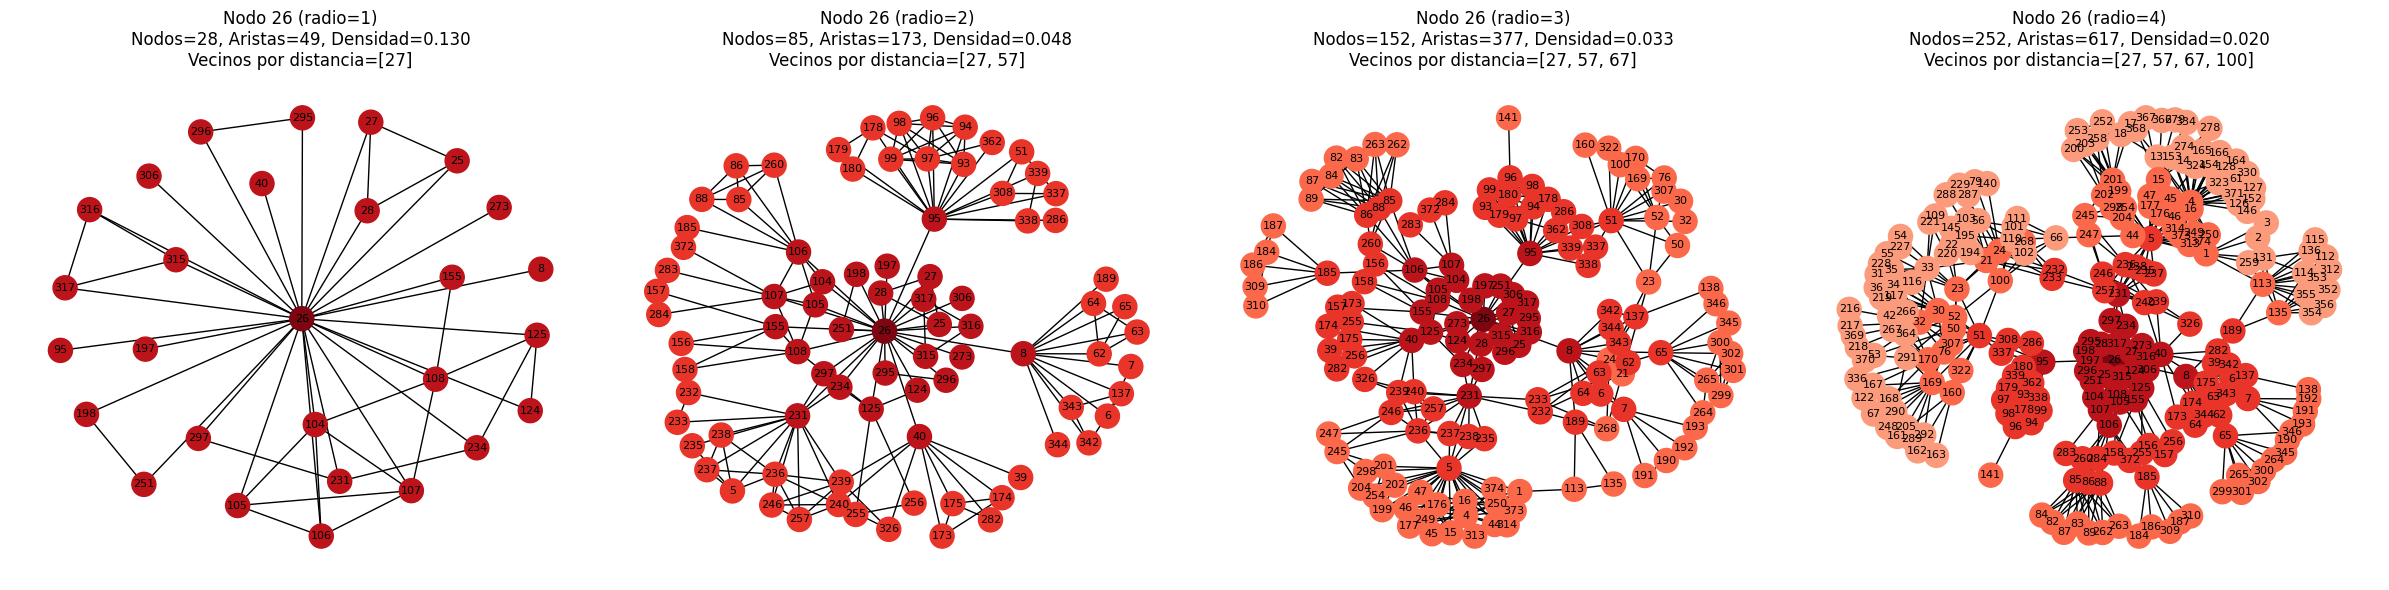

In [21]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

# Interpretacion

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

PageRank y centralidad se parecen mucho, porque caminar aleatoriamente en una grafica no dirigido termina visitando mas a los nodos con mas conexiones.

Eigenvector y Katz son diferentes a los otros dos y mide pertenecer al nucleo. No es solo cuantos coautores tienes, sino con quien colabora. Sus tops se parecen entre si y destacan a 4, 5, 16, 15, y luego a un bloque (45, 46, 47, 176, 177, 250) que es como un subgrupo denso/central.

Esto nos dice que la red tiene una estructura con diferencias entre nucleo y periferia aunque la red sea un solo componente, hay hubs perifericos (muchas colaboraciones pero con vecinos menos centrales) suben en grado/PageRank y bajan en eigenvector/Katz (ej. 26), mientras que el nucleo (colaboracion dentro del grupo central con vecinos importantes) sube en eigenvector/Katz sin necesitar el mayor grado (ej. 45–47, 176–177).

Por ejemplo: 4 y 5 salen fuertes en todo porque combinan ambas cosas: son grandes conectores y estan incrustados en el nucleo.
16 tambien es como pivote del nucleo.
26 destaca mas por volumen (muchos coautores).

Si subes en grado/PageRank, puedes estar rodeado de muchos nodos pero no necesariamente centrales; si subes en eigenvector/Katz, tipicamente estas rodeado por nodos centrales (estas “dentro” del nucleo). PageRank refuerza la lectura de popularidad por conexiones, y Katz refuerza la lectura de prestigio por conexion al nucleo.

Que la red de coautores haya convergido con $\alpha\approx 0.09$ (y la de Star Wars con $\alpha\approx 0.08$) es consistente con que Star Wars sea mas fuerte espectralmente (tiene un nucleo mas denso y/o conexiones efectivamente mas intensas), lo que obliga a un $\alpha$ un poco menor para que Katz no  explote. La red de coautores seria ligeramente menos intensa en ese sentido, por eso tolera un $\alpha$ un poco mayor. En Star Wars la influencia se recircula mas por nucleo; en coautores hay recirculacion un poco menos agresiva, asi que Katz necesita menos amortiguamiento.


# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


**Hacen articulos con muchas personas, sus vecinos colaboran con pocas otras personas a comparacion de el. Por ejemplo, el nodo 26 hace el 1.4% de todas las conexiones de la red, pero muchos nodos vecinos no tienen conexiones.**


## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**Hacen articulos con pocas personas a comparacion de todas las colaboraciones que tienen sus vecinos. En este caso, el nodo 4 si hace mas colaboraciones que el nodo 27 (del caso pasado), pero sus vecinos si siguen haciendo colaboraciones con otras personas, lo que hace que la red sea mas densa que la pasada.**


## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Se observa como tienen una densidad mayor que las otras dos redes.**


## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**Todos son negativos, entonces los mas extremos son los que tienen pocos vecinos y sus vecinos son muy importantes, estan muy bien conectados en la red, no por tener muchos vecinos, si no porque sus vecinos tambien son importantes.**
